In [198]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

#Two new packages!
import xarray as xr
import cartopy.crs as ccrs

In [199]:
ds = xr.open_dataset(r"C:\Users\user\Downloads\GEOS-CF_AirQuality_20180101_0030z.nc4")

In [200]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [201]:
O3 = ds.O3

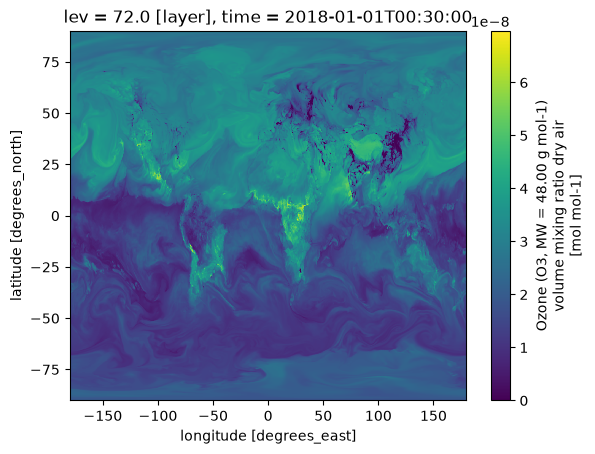

In [202]:
O3.plot()

Text(0.5, 1.0, 'Global O3 Concentration')

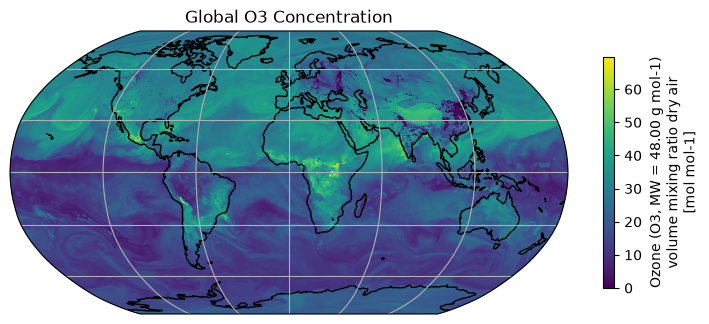

In [203]:
#Elementwise vs matrix operations
O3 = ds.O3 * 1e9 # units in ppb

#Plotting basics
#coordinate reference system (map projection)
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.5}) # line just makes the axis smaller and easier to read
ax.coastlines()
ax.gridlines()
ax.set_title("Global O3 Concentration")

In [204]:
plt.show()

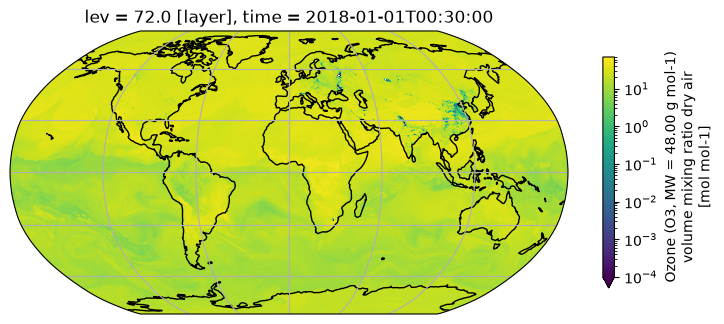

In [205]:
# Let's get log axes!

O3 = ds.O3*1e9
O3_positive = O3.where(O3>0.0001) #keeping only positive values because the log scale can't display zero

fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3.plot(ax=ax, transform=ccrs.PlateCarree(),
        norm=colors.LogNorm(vmin=0.0001,vmax=70), # Normalize the colorbar in log scale
        cbar_kwargs={'shrink': 0.5},)
ax.coastlines()
ax.gridlines()

In [206]:
O3.sel(lat=[32.2540], lon=[-110.9742], method="nearest")

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[33.12016]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 32.25
  * lon      (lon) float64 8B -111.0
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

In [207]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

In [208]:
O3 = ds["O3"].isel(time=0, lev=0) * 1e9
high_O3= O3. where(O3 >= O3.quantile(0.90, skipna= True))
O3.attrs["units"] = "ppb"

Text(0.5, 1.0, 'Areas with Qualitatively High O3')

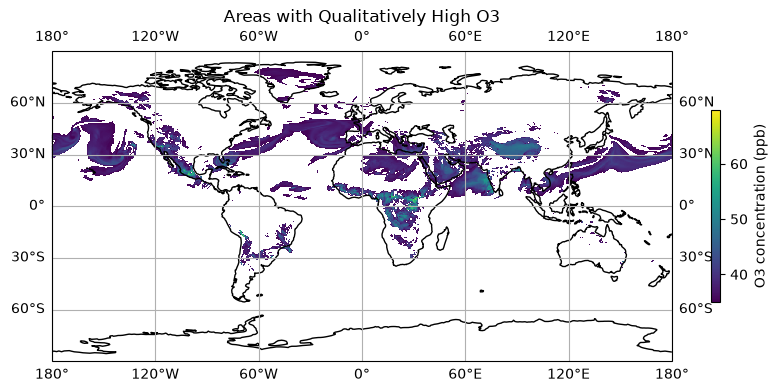

In [209]:
high_O3 = O3.where(O3 >= high_limit)

fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())

high_O3.plot(ax=ax, transform=ccrs.PlateCarree(),
             cbar_kwargs={'shrink': 0.5,'label': 'O3 concentration (ppb)'})

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_title("Areas with Qualitatively High O3")

In [210]:
max_position = np.unravel_index(np.nanargmax(O3.values),O3.shape)

In [211]:
max_lat = float(O3.lat.values[max_position[0]])
max_lon = float(O3.lon.values[max_position[1]])
max_O3 = float(O3.values[max_position])

In [212]:
print("Highest O3:", round(max_O3, 3), "ppb")
print("Latitude:", max_lat)
print("Longitude:", max_lon)

Highest O3: 69.733 ppb
Latitude: 34.5
Longitude: -118.75


Text(0.5, 1.0, 'Location of Highest O3')

C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:483: UserWarning: Creating legend with loc="be

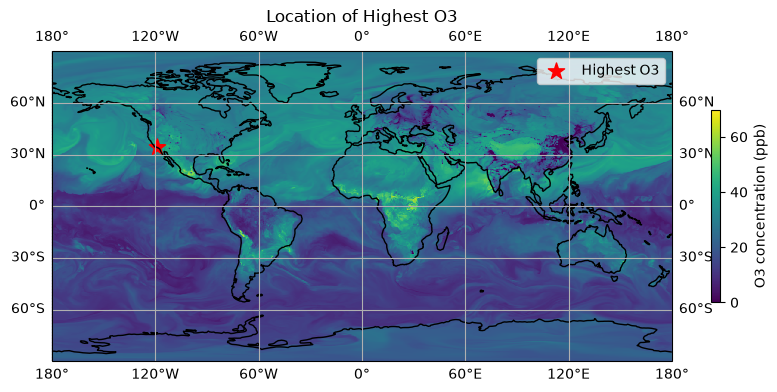

In [213]:
fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
O3.plot(ax=ax, transform=ccrs.PlateCarree(),
        cbar_kwargs={'shrink': 0.5,'label': 'O3 concentration (ppb)'})
ax.scatter(max_lon, max_lat, color="red", marker="*", s=150, transform=ccrs.PlateCarree(),label="Highest O3")
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.legend()
ax.set_title("Location of Highest O3")

In [214]:
O3_above_limit = O3.where(O3 > 0)

In [215]:
min_position = np.unravel_index(np.nanargmin(O3_above_limit.values),O3_above_limit.shape)

In [216]:
min_lat = float(O3_above_limit.lat.values[min_position[0]])
min_lon = float(O3_above_limit.lon.values[min_position[1]])
min_O3 = float(O3_above_limit.values[min_position])

In [217]:
print("lowest O3 above 0 ppb:",(min_O3,), "ppb")
print("Latitude:", min_lat)
print("Longitude:", min_lon)

lowest O3 above 0 ppb: (6.2632594423350785e-12,) ppb
Latitude: 55.75
Longitude: 38.75


Text(0.5, 1.0, 'Areas with Qualitatively Low O3')

C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:483: UserWarning: Creating legend with loc="be

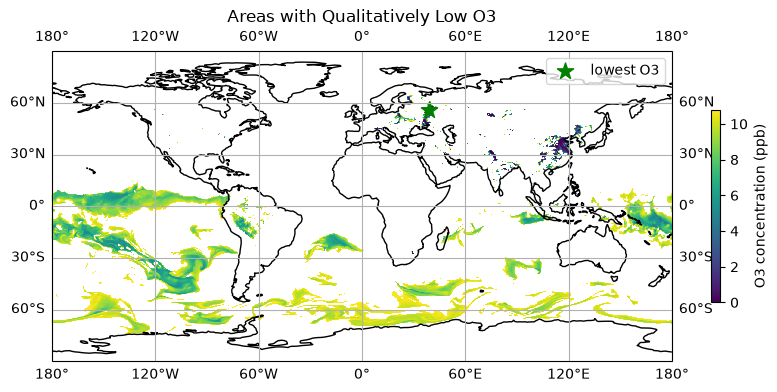

In [218]:
low_limit = float(O3_above_limit.quantile(0.10, skipna=True))
low_O3 = O3_above_limit.where(O3_above_limit<= low_limit)
fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
low_O3.plot(ax=ax, transform=ccrs.PlateCarree(),
            cbar_kwargs={'shrink': 0.5, 'label': 'O3 concentration (ppb)'})
ax.scatter(min_lon, min_lat, color="green", marker="*", s=150, transform=ccrs.PlateCarree(),label="lowest O3")
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.legend()
ax.set_title("Areas with Qualitatively Low O3")

In [219]:
min_position = np.unravel_index(np.nanargmin(O3.values),O3.shape)

O3 over USC, Los Angeles: 45.402 ppb
Selected latitude: 34.0
Selected longitude: -118.25


C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with 

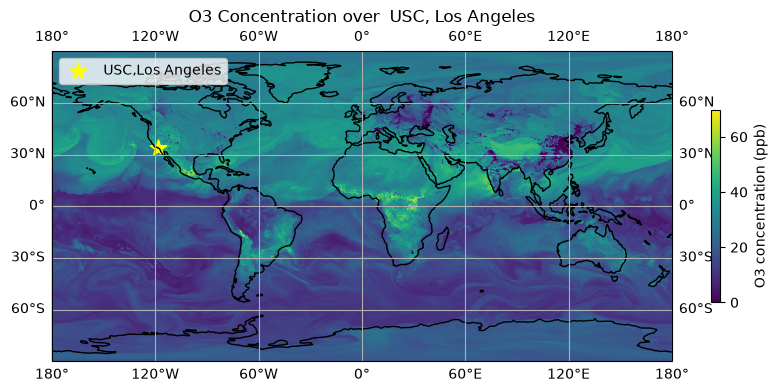

In [220]:
LA_lat = 34.01909
LA_lon= -118.28671
method="nearest"
print("O3 over USC, Los Angeles:", round(float(LA), 3), "ppb")
print("Selected latitude:", float(LA.lat))
print("Selected longitude:", float(LA.lon))
fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
O3.plot(ax=ax, transform=ccrs.PlateCarree(),cbar_kwargs={'shrink': 0.5,'label': 'O3 concentration (ppb)'})

ax.scatter(float(LA.lon), float(LA.lat),color="yellow", marker="*", s=150,transform=ccrs.PlateCarree(),label="USC,Los Angeles")

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.legend()
ax.set_title("O3 Concentration over  USC, Los Angeles")

plt.show()

O3 over northwestern coast of O'ahu Hawaii: 35.507 ppb
Selected latitude: 21.25
Selected longitude: -157.75


C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
C:\Users\user\anaconda3\envs\geol415\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with 

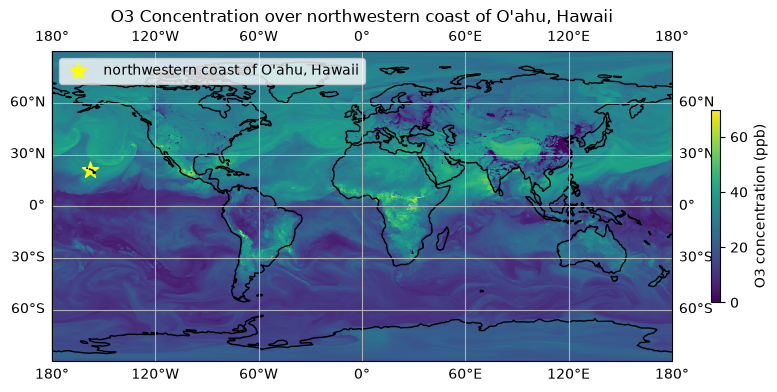

In [221]:
Hawaii_lat= 21.31
Hawaii_lon= -157.86
method="nearest"
print("O3 over northwestern coast of O'ahu Hawaii:", round(float(Hawaii), 3), "ppb")
print("Selected latitude:", float(Hawaii.lat))
print("Selected longitude:", float(Hawaii.lon))
fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
O3.plot(ax=ax, transform=ccrs.PlateCarree(),cbar_kwargs={'shrink': 0.5,'label': 'O3 concentration (ppb)'})

ax.scatter(float(Hawaii.lon), float(Hawaii.lat),color="yellow", marker="*", s=150,transform=ccrs.PlateCarree(),label="northwestern coast of O'ahu, Hawaii")

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.legend()
ax.set_title("O3 Concentration over northwestern coast of O'ahu, Hawaii")

plt.show()